# Imports

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

# Load Data

In [2]:
info = pd.read_csv("studentInfo.csv", na_values="?")
assess = pd.read_csv("studentAssessment.csv", na_values="?")

In [3]:
info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [4]:
assess.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [5]:
print(info.shape)
print(assess.shape)

(32593, 12)
(173912, 5)


# Clean Data

In [6]:
# convert values in scores column into numbers, if the value is other than number (e.g. N/A or ?), put NaN instead
assess['score'] = pd.to_numeric(assess['score'], errors='coerce')

# delete any row where the score column is NaN
assess = assess.dropna(subset=['score'])

In [7]:
print(assess.shape)

(173739, 5)


# Create Answer Columns

- The `final_result` column in the info dataset has 4 different values viz Pass, Distinction, Fail, and Withdrawn
- To simplify the classification, we want to convert that one column into 4 different columns so, we can use 0 and 1 to label whether Pass is yes or no or Distinction is yes or no.
- This is what the model will be trained on to predict the outcome

In [8]:
info['passed'] = info['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0,
})
info.shape

(32593, 13)

In [9]:
# remove rows from the dataset where the value of 'passed' column is empty
info = info.dropna(subset=['passed'])
info.shape

(32593, 13)

In [10]:
# converting decimal values to integers in passed column using astype()
info['passed'] = info['passed'].astype(int)

In [11]:
# count the number of students passed/failed
pass_counts = info['passed'].value_counts()
print(f"   Pass (1): {pass_counts[1]} students  ({pass_counts[1]/len(info)*100:.1f}%)")
print(f"   Fail (0): {pass_counts[0]} students  ({pass_counts[0]/len(info)*100:.1f}%)")

   Pass (1): 15385 students  (47.2%)
   Fail (0): 17208 students  (52.8%)


# Summarize Scores for Each Student

- The assessment file has multiple rows per student (one per quiz)
- We need one row per student to combine with their profile
- So, all of the quiz rows will be collapsed into number of quizzes, score average, and standard deviation to understand their consistency

In [12]:
# Using groupby() to combine all the rows that belong to the same student
# and agg() to calculate average, standard deviation, and total number of quizzes
student_features = assess.groupby('id_student').agg(
    avg_score = ('score', 'mean'),
    score_std = ('score', 'std'),
    num_assessments = ('score', 'count')
).reset_index()

student_features

,id_student,avg_score,score_std,num_assessments
0,6516,61.800000,10.329569,5
1,8462,87.000000,4.472136,7
2,11391,82.000000,3.082207,5
3,23629,82.500000,20.273135,4
4,23698,74.444444,13.258121,9
...,...,...,...,...
23346,2698251,58.142857,14.415600,7
23347,2698257,67.800000,7.362065,5
23348,2698535,39.250000,19.564910,8
23349,2698577,64.400000,19.969977,5


# Combine Tables
- Merging the info and student_features tables together

In [13]:
# Merging the two tables using the student ID via merge()
# `how='inner'` means similar inner join in SQL i.e.
# keep the rows that exist in both tables
df = pd.merge(info, student_features, on='id_student', how='inner')
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,passed,avg_score,score_std,num_assessments
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,3.082207,5
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,4.335897,5
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,6.892024,5
3,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,20.513410,5
4,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,1,68.0,10.977249,5


In [14]:
df.shape

(26727, 16)

# Charts to Understand Data

## Chart 01: Pass vs. Fail Count
- How many students passed vs. failed?
- A bar chart:
  - red bar = failed
  - green bar = passed
 
## Chart 02: Average Score
- Do students who pass score higher on average?
- Two overlapping histograms - one for students who passed and one for students who failed
- If the two histograms overlap a lot, scores alone do not tell us much
- If they are far apart, scores are a strong predictor

## Chart 03: Credits vs Pass Rate
- Does taking more credits affect passing?
- Grouping students by how many credits they studied, then calculating pass rate for each group.

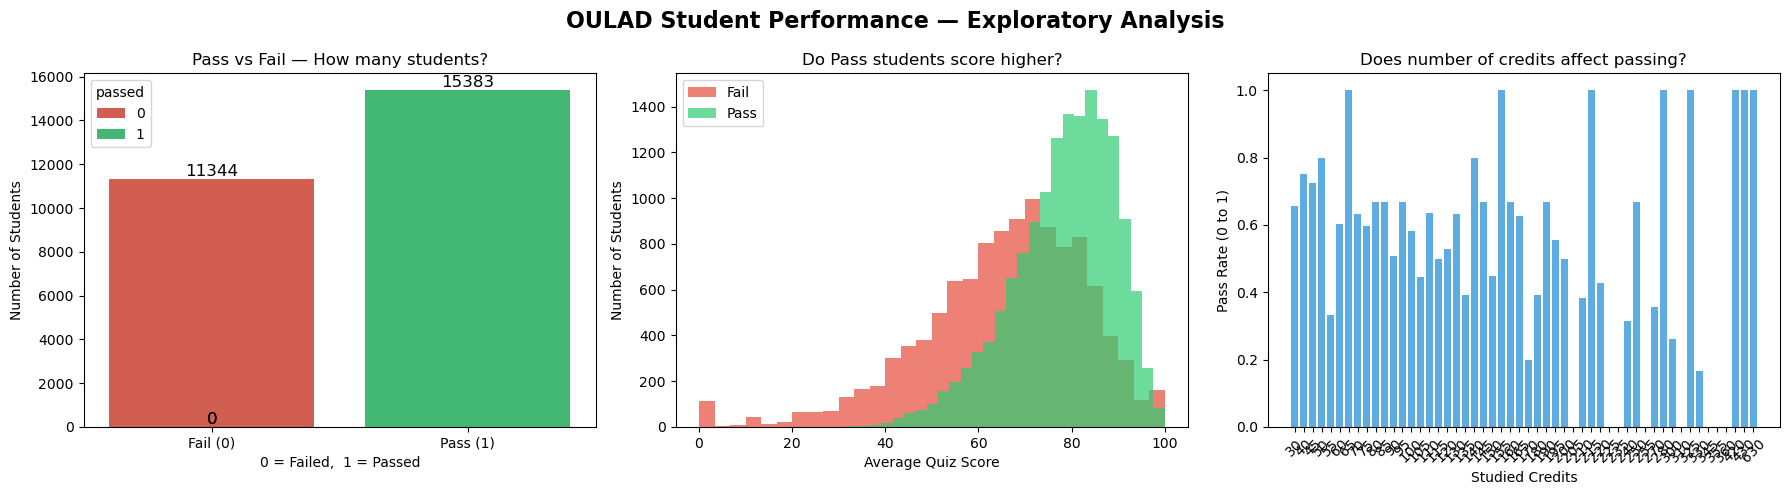

In [20]:
# Make a canvas with 3 charts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('OULAD Student Performance — Exploratory Analysis', fontsize=16, fontweight='bold')

# -------------------------------
# Chart 1: Pass vs Fail Count
# -------------------------------
sns.countplot(x='passed', data=df, hue='passed', palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Pass vs Fail — How many students?')
axes[0].set_xlabel('0 = Failed,  1 = Passed')
axes[0].set_ylabel('Number of Students')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# -------------------------------
# Chart 2: Average Score
# -------------------------------
fail_scores = df[df['passed'] == 0]['avg_score']
pass_scores = df[df['passed'] == 1]['avg_score']

axes[1].hist(fail_scores, bins=30, alpha=0.7, color='#e74c3c', label='Fail')
axes[1].hist(pass_scores, bins=30, alpha=0.7, color='#2ecc71', label='Pass')
axes[1].set_title('Do Pass students score higher?')
axes[1].set_xlabel('Average Quiz Score')
axes[1].set_ylabel('Number of Students')
axes[1].legend()

# -------------------------------
# Chart 3: Credits vs Pass Rate
# -------------------------------
credit_pass = df.groupby('studied_credits')['passed'].mean().reset_index()
axes[2].bar(credit_pass['studied_credits'].astype(str), credit_pass['passed'],
            color='#3498db', alpha=0.8)
axes[2].set_title('Does number of credits affect passing?')
axes[2].set_xlabel('Studied Credits')
axes[2].set_ylabel('Pass Rate (0 to 1)')
axes[2].tick_params(axis='x', rotation=45)

# Show charts
plt.tight_layout()
plt.show()